# 딥러닝 응용 - CNN 기반 이미지 불량 검출

## 학습 목표

1. **CNN 구조 이해** 합성곱 신경망의 구조와 각 층의 역할을 이해함
2. **수식 전개** 합성곱 연산, 다채널 확장, 특성 맵 크기 계산의 수학적 원리를 학습함
3. **시각적 이해** CNN의 각 연산(합성곱, 풀링)을 시각적으로 이해함
4. **YOLO 이해** 객체 탐지 모델 YOLO의 기본 개념과 활용 방법을 이해함

## 실습 데이터셋

본 강의에서는 이전 차시와의 차별성을 위해 다음 데이터셋을 활용함:

| 데이터셋 | 출처 | 용도 | 특징 |
|---------|------|------|------|
| **NEU Surface Defect Database** | 동북대학교(중국) | 철강 표면 결함 분류 | 6종 결함, 1,800장, 200x200 픽셀 |
| Casting Product Image | Kaggle | 주조 제품 결함 이진 분류 | 약 7,000장, 정상/불량 |

**NEU Surface Defect Database 결함 유형:**
- **Cr (Crazing)**: 균열 패턴
- **In (Inclusion)**: 개재물
- **Pa (Patches)**: 패치/얼룩
- **PS (Pitted Surface)**: 피팅 표면
- **RS (Rolled-in Scale)**: 압연 스케일
- **Sc (Scratches)**: 스크래치

```python
# NEU Surface Defect Database 다운로드
# http://faculty.neu.edu.cn/songkechen/zh_CN/zdylm/263270/list/
# 또는 Kaggle: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database

# 디렉토리 구조:
# NEU-DET/
#   train/
#     Cr/  (300장)
#     In/  (300장)
#     Pa/  (300장)
#     PS/  (300장)
#     RS/  (300장)
#     Sc/  (300장)
```

# 1: CNN 이론 및 수학적 배경

## 1.1 왜 CNN인가? - 이미지 처리의 도전

### 전통적인 MLP(다층 퍼셉트론)의 한계

이미지를 MLP로 처리할 때의 문제점을 살펴보자:

| 문제 | 설명 | 예시 |
|------|------|------|
| **파라미터 폭발** | 이미지를 1차원으로 펼치면 가중치 수가 폭발적으로 증가함 | 200x200 흑백 이미지 -> 40,000개 입력 |
| **공간 정보 손실** | 이미지를 펼치면 픽셀 간의 공간적 관계가 사라짐 | 인접 픽셀의 관계 무시됨 |
| **위치 불변성 부재** | 같은 패턴이 다른 위치에 있으면 새로운 패턴으로 인식함 | 좌측 스크래치 ≠ 우측 스크래치 |

**수치 예시 - 파라미터 수 비교:**

$$\text{MLP 첫 번째 은닉층 (512 뉴런)}: 200 \times 200 \times 512 = 20,480,000 \text{ 파라미터}$$

$$\text{CNN 첫 번째 합성곱층 (32 필터, 3x3)}: 3 \times 3 \times 1 \times 32 + 32 = 320 \text{ 파라미터}$$

CNN은 파라미터를 약 **64,000배** 줄이면서도 공간 정보를 보존함.

### CNN의 핵심 아이디어

CNN(Convolutional Neural Network, 합성곱 신경망)은 세 가지 핵심 아이디어로 이미지 처리에 특화됨:

```mermaid
flowchart LR
    subgraph 핵심아이디어["CNN의 3가지 핵심 아이디어"]
        A["지역적 연결성<br/>Local Connectivity"] --> D["작은 영역에서<br/>특징 추출"]
        B["가중치 공유<br/>Weight Sharing"] --> E["동일 필터를<br/>전체 이미지에 적용"]
        C["계층적 특징 학습<br/>Hierarchical Learning"] --> F["저수준 → 고수준<br/>특징 추출"]
    end
    
    D --> G["파라미터 감소"]
    E --> G
    F --> H["위치 불변 특징"]
```

| 개념 | 설명 | 효과 |
|------|------|------|
| 지역적 연결성 | 각 뉴런이 전체가 아닌 작은 영역(커널 크기)만 봄 | 파라미터 수 대폭 감소 |
| 가중치 공유 | 동일한 필터(가중치)가 이미지 전체를 순회함 | 위치에 관계없이 동일 패턴 검출 |
| 계층적 학습 | 초기 층은 엣지, 후반 층은 복잡한 형태 학습 | 점진적 추상화 |

## 1.2 합성곱 연산의 수학적 정의

### 단채널 2D 합성곱 (Convolution)

입력 이미지 $I$와 커널(필터) $K$의 2D 합성곱 연산은 다음과 같이 정의됨:

$$
(I * K)(i,j) = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} I(i+m, j+n) \cdot K(m,n)
$$

| 기호 | 의미 | 예시 |
|------|------|------|
| $I$ | 입력 이미지 (2D 행렬) | 200x200 픽셀 이미지 |
| $K$ | 커널/필터 (작은 2D 행렬) | 3x3 필터 |
| $(i,j)$ | 출력 특성 맵의 위치 | 출력의 좌표 |
| $(m,n)$ | 커널 내부의 상대 위치 | 0~2 범위 |
| $k_h, k_w$ | 커널의 높이, 너비 | 각각 3 |

**직관적 이해:**
- 커널이 이미지 위를 슬라이딩하면서 이동함
- 각 위치에서 커널과 해당 영역의 **요소별 곱셈 후 합산**을 수행함
- 결과는 **특성 맵(Feature Map)** 이라 불리는 새로운 2D 배열임

### 다채널 합성곱 연산

실제 이미지(RGB)나 중간 특성 맵은 여러 채널을 가짐. 다채널 합성곱은 다음과 같음:

$$
O_{c_{out}}(i,j) = b_{c_{out}} + \sum_{c_{in}=0}^{C_{in}-1} \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} I_{c_{in}}(i+m, j+n) \cdot K_{c_{out}, c_{in}}(m,n)
$$

| 기호 | 의미 | 예시 |
|------|------|------|
| $C_{in}$ | 입력 채널 수 | RGB면 3, 흑백이면 1 |
| $C_{out}$ | 출력 채널 수 (필터 개수) | 32개 필터 사용 시 32 |
| $c_{out}$ | 출력 채널(필터) 인덱스 | 0~31 |
| $c_{in}$ | 입력 채널 인덱스 | 0~2 (RGB) |
| $b_{c_{out}}$ | 편향(bias) 항 | 필터별 1개 |
| $K_{c_{out}, c_{in}}$ | c_out번째 필터의 c_in번째 채널 커널 | 3x3 크기 |

**핵심 포인트:**
- 각 필터는 **모든 입력 채널**에 대한 커널을 가짐
- 하나의 필터가 만드는 출력은 **하나의 채널** (모든 입력 채널 합산 결과)
- 32개 필터 → 32채널 출력

### 특성 맵 크기 계산

합성곱 연산 후 출력 크기는 다음 공식으로 계산됨:

$$
O = \left\lfloor \frac{W - K + 2P}{S} \right\rfloor + 1
$$

| 기호 | 의미 | 일반적 값 |
|------|------|----------|
| $O$ | 출력 크기 | 계산 결과 |
| $W$ | 입력 크기 | 200 (NEU 데이터셋) |
| $K$ | 커널 크기 | 3 (3x3 필터) |
| $P$ | 패딩 (Padding) | 0 또는 1 |
| $S$ | 스트라이드 (Stride) | 1 또는 2 |

**계산 예시 (NEU 데이터셋, 200x200 입력):**

| 설정 | 계산 | 결과 |
|------|------|------|
| K=3, P=0, S=1 | $\lfloor(200-3+0)/1\rfloor+1$ | 198x198 |
| K=3, P=1, S=1 | $\lfloor(200-3+2)/1\rfloor+1$ | 200x200 (same) |
| K=3, P=0, S=2 | $\lfloor(200-3+0)/2\rfloor+1$ | 99x99 |

### 풀링 연산 (Pooling)

풀링은 특성 맵의 크기를 줄이면서 중요한 정보를 유지하는 연산임:

**Max Pooling:**
$$
y_{ij} = \max_{(m,n) \in R_{ij}} x_{mn}
$$

**Average Pooling:**
$$
y_{ij} = \frac{1}{|R_{ij}|} \sum_{(m,n) \in R_{ij}} x_{mn}
$$

| 기호 | 의미 |
|------|------|
| $y_{ij}$ | 출력 위치 $(i,j)$의 값 |
| $R_{ij}$ | 풀링 영역 (예: 2x2) |
| $x_{mn}$ | 영역 내 입력값 |

**풀링의 효과:**
- **공간 크기 축소**: 계산량 감소
- **위치 불변성**: 작은 위치 변화에 강건함
- **과적합 방지**: 파라미터 없이 차원 축소

## 1.3 CNN 전체 구조

```mermaid
flowchart TB
    subgraph Input["입력층"]
        A["입력 이미지<br/>200x200x1"]
    end

    subgraph Conv1["합성곱 블록 1"]
        B["Conv2D(32, 3x3, relu)<br/>198x198x32"]
        C["MaxPooling2D(2x2)<br/>99x99x32"]
    end

    subgraph Conv2["합성곱 블록 2"]
        D["Conv2D(64, 3x3, relu)<br/>97x97x64"]
        E["MaxPooling2D(2x2)<br/>48x48x64"]
    end

    subgraph Conv3["합성곱 블록 3"]
        F["Conv2D(128, 3x3, relu)<br/>46x46x128"]
        G["MaxPooling2D(2x2)<br/>23x23x128"]
    end

    subgraph FC["완전연결층"]
        H["Flatten<br/>67,712"]
        I["Dense(128, relu)"]
        J["Dropout(0.5)"]
        K["Dense(6, softmax)"]
    end

    subgraph Output["출력층"]
        L["6개 결함 클래스 확률"]
    end

    A --> B --> C --> D --> E --> F --> G --> H --> I --> J --> K --> L
```

| 층 유형 | 역할 | 주요 파라미터 |
|--------|------|--------------|
| Conv2D | 지역적 특징 추출 (엣지, 질감 등) | 필터 수, 커널 크기, 활성화 함수 |
| MaxPooling2D | 공간 크기 축소, 위치 불변성 확보 | 풀링 크기 |
| Flatten | 다차원을 1차원으로 변환 | 없음 |
| Dense | 추출된 특징으로 분류 수행 | 뉴런 수, 활성화 함수 |
| Dropout | 과적합 방지 (학습 시 일부 뉴런 비활성화) | 드롭 비율 |

# 2: CNN 연산의 시각적 이해

## 2.1 합성곱 연산 수동 계산 및 시각화

합성곱이 실제로 어떻게 동작하는지 직접 계산해보ㅈ!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

def convolution_2d_manual(image, kernel):
    """
    2D 합성곱 연산을 수동으로 계산
    
    수식: (I * K)(i,j) = sum_m sum_n I(i+m, j+n) * K(m,n)
    
    Parameters:
        image: 2D numpy 배열 (입력 이미지)
        kernel: 2D numpy 배열 (필터)
    
    Returns:
        output: 2D numpy 배열 (특성 맵)
    """
    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape
    
    # 출력 크기 계산: O = W - K + 1 (패딩 0, 스트라이드 1)
    out_h = img_h - ker_h + 1
    out_w = img_w - ker_w + 1
    
    output = np.zeros((out_h, out_w))
    
    for i in range(out_h):
        for j in range(out_w):
            # 현재 위치의 영역 추출
            region = image[i:i+ker_h, j:j+ker_w]
            # 요소별 곱셈 후 합산
            output[i, j] = np.sum(region * kernel)
    
    return output

# 예시: 5x5 입력, 3x3 커널
image = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 2],
    [7, 8, 9, 2, 3],
    [1, 0, 1, 4, 5],
    [2, 3, 2, 1, 0]
], dtype=float)

# 엣지 검출 필터 (수평 엣지)
kernel_edge = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=float)

# 합성곱 연산 수행
output = convolution_2d_manual(image, kernel_edge)

print("입력 이미지 (5x5):")
print(image.astype(int))
print("\n커널 - Sobel 수평 엣지 (3x3):")
print(kernel_edge.astype(int))
print("\n합성곱 결과 (3x3):")
print(output.astype(int))

입력 이미지 (5x5):
[[1 2 3 0 1]
 [4 5 6 1 2]
 [7 8 9 2 3]
 [1 0 1 4 5]
 [2 3 2 1 0]]

커널 - Sobel 수평 엣지 (3x3):
[[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]

합성곱 결과 (3x3):
[[ 24  20  12]
 [-18 -12   4]
 [-22 -20 -12]]


### 합성곱 계산 과정 상세 설명

위치 (0,0)에서의 계산 예시:

$$
\begin{aligned}
\text{Output}(0,0) &= \sum_{m=0}^{2} \sum_{n=0}^{2} I(m, n) \cdot K(m,n) \\
&= 1 \times (-1) + 2 \times (-2) + 3 \times (-1) \\
&+ 4 \times 0 + 5 \times 0 + 6 \times 0 \\
&+ 7 \times 1 + 8 \times 2 + 9 \times 1 \\
&= (-1 - 4 - 3) + (0) + (7 + 16 + 9) \\
&= -8 + 32 = 24
\end{aligned}
$$

합성곱 연산 단계별 시각화 - 위치 (0,0)


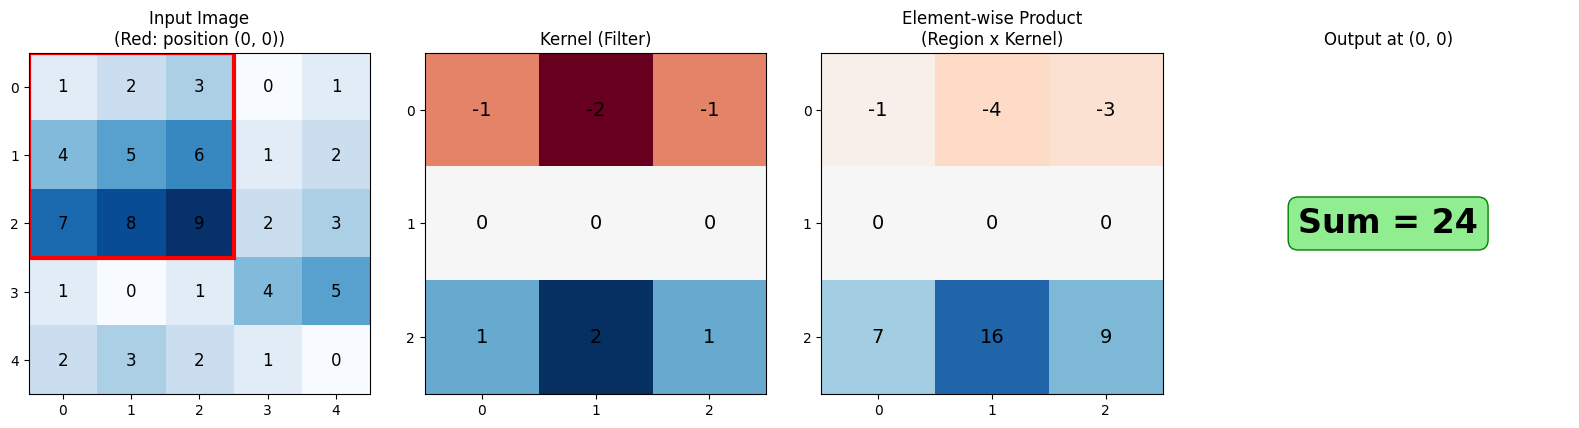

np.float64(24.0)

In [2]:
def visualize_convolution_step(image, kernel, position=(0, 0)):
    """
    합성곱 연산의 특정 위치에서의 계산 과정을 시각화
    """
    i, j = position
    ker_h, ker_w = kernel.shape
    
    # 해당 영역 추출
    region = image[i:i+ker_h, j:j+ker_w]
    
    # 요소별 곱
    elementwise = region * kernel
    
    # 결과
    result = np.sum(elementwise)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # 1. 입력 이미지 (영역 표시)
    ax = axes[0]
    im = ax.imshow(image, cmap='Blues')
    rect = patches.Rectangle((j-0.5, i-0.5), ker_w, ker_h,
                              linewidth=3, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    for x in range(image.shape[0]):
        for y in range(image.shape[1]):
            ax.text(y, x, f'{image[x,y]:.0f}', ha='center', va='center', fontsize=12)
    ax.set_title(f'Input Image\n(Red: position {position})', fontsize=12)
    ax.set_xticks(range(image.shape[1]))
    ax.set_yticks(range(image.shape[0]))
    
    # 2. 커널
    ax = axes[1]
    ax.imshow(kernel, cmap='RdBu', vmin=-2, vmax=2)
    for x in range(kernel.shape[0]):
        for y in range(kernel.shape[1]):
            ax.text(y, x, f'{kernel[x,y]:.0f}', ha='center', va='center', fontsize=14)
    ax.set_title('Kernel (Filter)', fontsize=12)
    ax.set_xticks(range(kernel.shape[1]))
    ax.set_yticks(range(kernel.shape[0]))
    
    # 3. 요소별 곱
    ax = axes[2]
    ax.imshow(elementwise, cmap='RdBu', vmin=-20, vmax=20)
    for x in range(elementwise.shape[0]):
        for y in range(elementwise.shape[1]):
            ax.text(y, x, f'{elementwise[x,y]:.0f}', ha='center', va='center', fontsize=14)
    ax.set_title(f'Element-wise Product\n(Region x Kernel)', fontsize=12)
    ax.set_xticks(range(elementwise.shape[1]))
    ax.set_yticks(range(elementwise.shape[0]))
    
    # 4. 결과
    ax = axes[3]
    ax.text(0.5, 0.5, f'Sum = {result:.0f}', ha='center', va='center',
            fontsize=24, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgreen', edgecolor='green'))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(f'Output at {position}', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    return result

# 위치 (0,0)에서의 계산 과정 시각화
print("=" * 60)
print("합성곱 연산 단계별 시각화 - 위치 (0,0)")
print("=" * 60)
visualize_convolution_step(image, kernel_edge, position=(0, 0))

합성곱 연산 단계별 시각화 - 위치 (1,1)


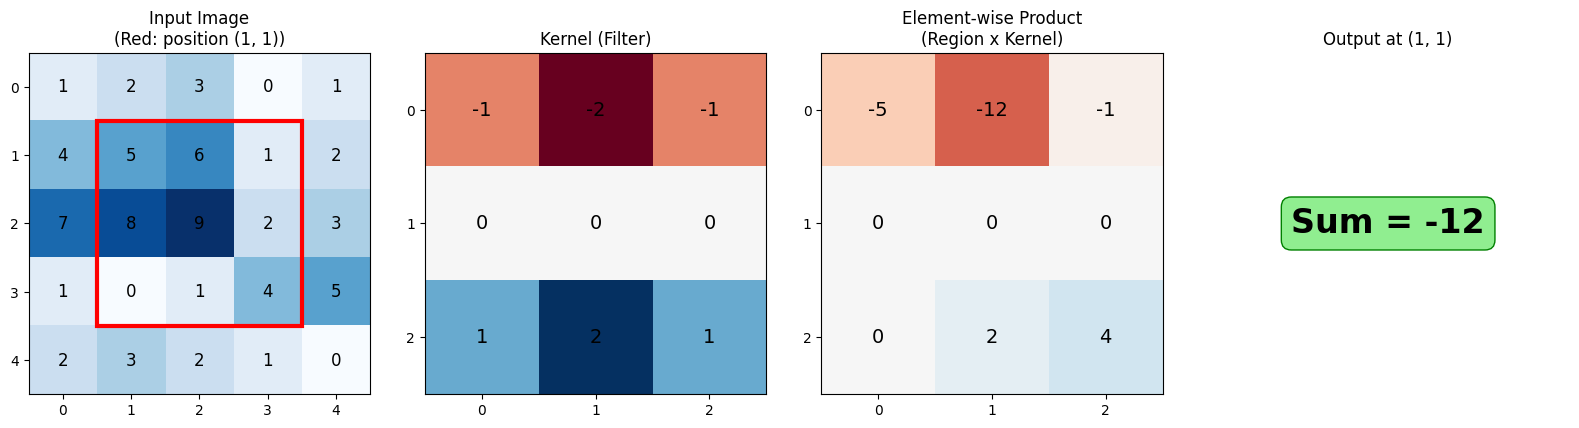

np.float64(-12.0)

In [3]:
# 다른 위치에서의 계산도 확인
print("=" * 60)
print("합성곱 연산 단계별 시각화 - 위치 (1,1)")
print("=" * 60)
visualize_convolution_step(image, kernel_edge, position=(1, 1))

## 2.2 풀링 연산 시각화

Max Pooling이 어떻게 동작하는지 시각적으로 확인해보자:

Max Pooling 연산 시각화

수식: y_ij = max_{(m,n) in R_ij} x_mn

각 2x2 영역에서 최댓값을 선택함



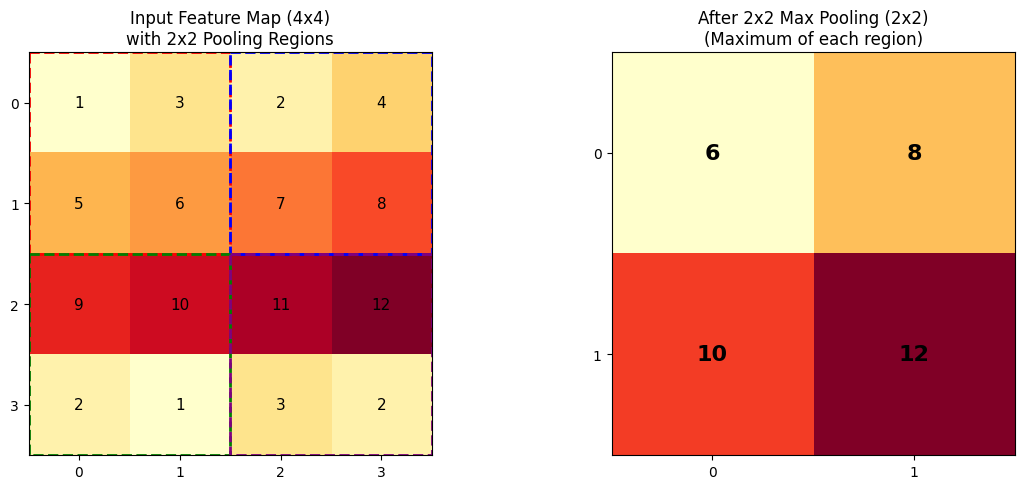


Max Pooling 계산 과정:
----------------------------------------
  좌상단 영역 [1,3,5,6] -> max = 6
  우상단 영역 [2,4,7,8] -> max = 8
  좌하단 영역 [9,10,2,1] -> max = 10
  우하단 영역 [11,12,3,2] -> max = 12


In [4]:
def max_pooling_2d_visualize(image, pool_size=2, stride=2):
    """
    2x2 Max Pooling 연산 및 시각화
    
    수식: y_ij = max_{(m,n) in R_ij} x_mn
    """
    h, w = image.shape
    out_h = (h - pool_size) // stride + 1
    out_w = (w - pool_size) // stride + 1
    
    output = np.zeros((out_h, out_w))
    
    # 시각화 준비
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 입력 특성 맵
    ax = axes[0]
    im = ax.imshow(image, cmap='YlOrRd')
    for x in range(h):
        for y in range(w):
            ax.text(y, x, f'{image[x,y]:.0f}', ha='center', va='center', fontsize=11)
    
    # 풀링 영역 표시
    colors = ['red', 'blue', 'green', 'purple']
    idx = 0
    for i in range(out_h):
        for j in range(out_w):
            rect = patches.Rectangle((j*stride-0.5, i*stride-0.5), 
                                     pool_size, pool_size,
                                     linewidth=2, edgecolor=colors[idx % 4], 
                                     facecolor='none', linestyle='--')
            ax.add_patch(rect)
            
            # 풀링 계산
            region = image[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            output[i, j] = np.max(region)
            idx += 1
    
    ax.set_title('Input Feature Map (4x4)\nwith 2x2 Pooling Regions', fontsize=12)
    ax.set_xticks(range(w))
    ax.set_yticks(range(h))
    
    # 출력 (풀링 결과)
    ax = axes[1]
    ax.imshow(output, cmap='YlOrRd')
    for x in range(out_h):
        for y in range(out_w):
            ax.text(y, x, f'{output[x,y]:.0f}', ha='center', va='center', 
                   fontsize=16, fontweight='bold')
    ax.set_title('After 2x2 Max Pooling (2x2)\n(Maximum of each region)', fontsize=12)
    ax.set_xticks(range(out_w))
    ax.set_yticks(range(out_h))
    
    plt.tight_layout()
    plt.show()
    
    return output

# 예시 특성 맵 (4x4)
feature_map = np.array([
    [1, 3, 2, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [2, 1, 3, 2]
], dtype=float)

print("=" * 60)
print("Max Pooling 연산 시각화")
print("=" * 60)
print("\n수식: y_ij = max_{(m,n) in R_ij} x_mn")
print("\n각 2x2 영역에서 최댓값을 선택함\n")

pooled = max_pooling_2d_visualize(feature_map)

print("\nMax Pooling 계산 과정:")
print("-" * 40)
print(f"  좌상단 영역 [1,3,5,6] -> max = 6")
print(f"  우상단 영역 [2,4,7,8] -> max = 8")
print(f"  좌하단 영역 [9,10,2,1] -> max = 10")
print(f"  우하단 영역 [11,12,3,2] -> max = 12")

## 2.3 다양한 필터의 효과 시각화

CNN이 학습하는 필터들이 실제로 어떤 특징을 검출하는지 확인해보자:

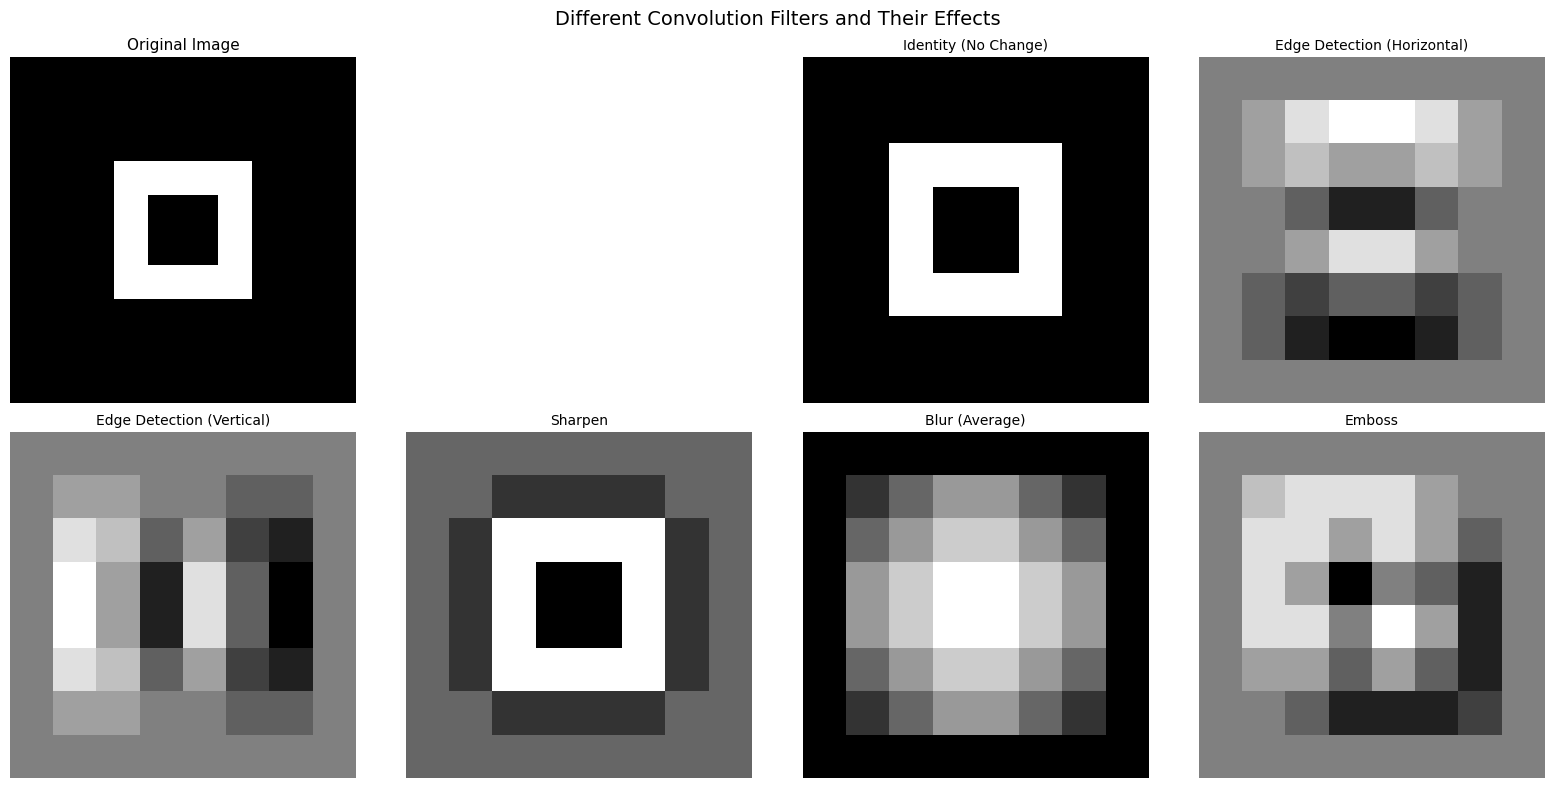


필터별 역할:
--------------------------------------------------
  - Identity: 이미지 그대로 유지
  - Edge (Horizontal/Vertical): 수평/수직 경계선 검출
  - Sharpen: 이미지 선명화
  - Blur: 이미지 흐림 (노이즈 감소)
  - Emboss: 입체감 효과

CNN은 학습을 통해 이러한 필터들을 자동으로 발견함!


In [5]:
# 다양한 필터 정의
filters = {
    'Identity (No Change)': np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]]),
    'Edge Detection (Horizontal)': np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),
    'Edge Detection (Vertical)': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
    'Sharpen': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
    'Blur (Average)': np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]]) / 9.0,
    'Emboss': np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]])
}

# 예시 이미지 생성 (간단한 패턴)
test_image = np.zeros((10, 10))
test_image[3:7, 3:7] = 1  # 중앙에 사각형
test_image[4:6, 4:6] = 0  # 내부 빈 공간

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# 원본 이미지
axes[0, 0].imshow(test_image, cmap='gray')
axes[0, 0].set_title('Original Image', fontsize=11)
axes[0, 0].axis('off')

# 빈 공간
axes[0, 1].axis('off')

# 각 필터 적용 결과
positions = [(0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3)]
for (name, kernel), (row, col) in zip(filters.items(), positions):
    result = convolution_2d_manual(test_image, kernel)
    axes[row, col].imshow(result, cmap='gray')
    axes[row, col].set_title(name, fontsize=10)
    axes[row, col].axis('off')

plt.suptitle('Different Convolution Filters and Their Effects', fontsize=14)
plt.tight_layout()
plt.show()

print("\n필터별 역할:")
print("-" * 50)
print("  - Identity: 이미지 그대로 유지")
print("  - Edge (Horizontal/Vertical): 수평/수직 경계선 검출")
print("  - Sharpen: 이미지 선명화")
print("  - Blur: 이미지 흐림 (노이즈 감소)")
print("  - Emboss: 입체감 효과")
print("\nCNN은 학습을 통해 이러한 필터들을 자동으로 발견함!")

# 3. 실제 데이터 기반 CNN 구현

## 3.1 환경 설정 및 라이브러리 로드

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# TensorFlow 경고 메시지 숨김
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

# GPU 사용 가능 여부 확인
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU Available: {len(gpus)} device(s)")
else:
    print("GPU Not Available - Using CPU")

TensorFlow Version: 2.20.0
Keras Version: 3.13.0
GPU Not Available - Using CPU


## 3.2 NEU Surface Defect 데이터셋 로드

**NEU Surface Defect Database 정보:**

| 항목 | 내용 |
|------|------|
| 출처 | 중국 동북대학교 (Northeastern University) |
| 이미지 크기 | 200 x 200 픽셀 |
| 채널 | 흑백 (Grayscale) |
| 클래스 수 | 6 (Cr, In, Pa, PS, RS, Sc) |
| 클래스당 이미지 | 300장 |
| 총 이미지 수 | 1,800장 |
| 적용 분야 | 철강 표면 품질 검사 |

In [26]:
# 데이터 경로 설정
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")

print("Path to dataset files:", path)

DATA_DIR = Path(path)

# 이미지 설정
IMG_HEIGHT = 200
IMG_WIDTH = 200
BATCH_SIZE = 32
NUM_CLASSES = 6

# 클래스 정보
CLASS_NAMES = ['Crazing', 'Inclusion', 'Patches', 'Pitted', 'Rolled', 'Scratches']
CLASS_CODES = ['Cr', 'In', 'Pa', 'PS', 'RS', 'Sc']

print("데이터셋 정보:")
print("=" * 50)
print(f"이미지 크기: {IMG_HEIGHT}x{IMG_WIDTH} 픽셀")
print(f"배치 크기: {BATCH_SIZE}")
print(f"클래스 수: {NUM_CLASSES}")
print("\n결함 유형:")
for code, name in zip(CLASS_CODES, CLASS_NAMES):
    print(f"  {code}: {name}")

Path to dataset files: C:\Users\oswar_000\.cache\kagglehub\datasets\kaustubhdikshit\neu-surface-defect-database\versions\1
데이터셋 정보:
이미지 크기: 200x200 픽셀
배치 크기: 32
클래스 수: 6

결함 유형:
  Cr: Crazing
  In: Inclusion
  Pa: Patches
  PS: Pitted
  RS: Rolled
  Sc: Scratches


In [27]:
# 데이터 불러오는 부분
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

def load_neu_dataset(data_dir, img_height=200, img_width=200):
    """
    NEU Surface Defect Database 로드
    
    Parameters:
    -----------
    data_dir : Path
        데이터셋 루트 디렉토리
    img_height : int
        리사이즈할 이미지 높이
    img_width : int
        리사이즈할 이미지 너비
    
    Returns:
    --------
    X : ndarray
        이미지 배열 (N, H, W, 1) - 그레이스케일
    y : ndarray
        레이블 배열 (N,)
    """
    images = []
    labels = []
    
    # NEU 데이터셋 구조 확인 (여러 가능한 경로 탐색)
    possible_paths = [
        data_dir / "NEU-DET" / "train" / "images",
        data_dir / "NEU-DET" / "images",
        data_dir / "NEU_surface_defect_database",
        data_dir / "images",
        data_dir
    ]
    
    # 실제 이미지가 있는 경로 찾기
    img_dir = None
    for path in possible_paths:
        if path.exists():
            # 해당 경로에 이미지 파일이 있는지 확인
            files = list(path.glob("*.bmp")) + list(path.glob("*.jpg")) + list(path.glob("*.png"))
            if files:
                img_dir = path
                break
            # 하위 폴더 확인
            for subdir in path.iterdir():
                if subdir.is_dir():
                    sub_files = list(subdir.glob("*.bmp")) + list(subdir.glob("*.jpg")) + list(subdir.glob("*.png"))
                    if sub_files:
                        img_dir = path
                        break
    
    if img_dir is None:
        # 전체 디렉토리 구조 출력하여 디버깅
        print("데이터셋 구조 탐색 중...")
        for root, dirs, files in os.walk(data_dir):
            level = root.replace(str(data_dir), '').count(os.sep)
            indent = ' ' * 2 * level
            print(f"{indent}{os.path.basename(root)}/")
            if level < 2:
                for file in files[:5]:
                    print(f"{indent}  {file}")
                if len(files) > 5:
                    print(f"{indent}  ... ({len(files)} files)")
        raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다: {data_dir}")
    
    print(f"이미지 디렉토리: {img_dir}")
    
    # 클래스별 폴더가 있는 경우 (폴더 구조)
    class_folders = [d for d in img_dir.iterdir() if d.is_dir()]
    
    if class_folders:
        # 폴더별 클래스 구조
        print("폴더 기반 데이터 로드...")
        for class_idx, class_code in enumerate(tqdm(CLASS_CODES, desc="클래스 로드")):
            # 클래스 폴더 찾기
            class_folder = None
            for folder in class_folders:
                if class_code.lower() in folder.name.lower() or CLASS_NAMES[class_idx].lower().replace(' ', '') in folder.name.lower().replace(' ', ''):
                    class_folder = folder
                    break
            
            if class_folder is None:
                # 폴더명이 클래스명과 정확히 일치하는 경우
                for folder in class_folders:
                    if folder.name == class_code or folder.name == CLASS_NAMES[class_idx]:
                        class_folder = folder
                        break
            
            if class_folder and class_folder.exists():
                img_files = list(class_folder.glob("*.bmp")) + list(class_folder.glob("*.jpg")) + list(class_folder.glob("*.png"))
                for img_path in img_files:
                    try:
                        img = Image.open(img_path).convert('L')  # 그레이스케일
                        img = img.resize((img_width, img_height))
                        img_array = np.array(img) / 255.0  # 정규화
                        images.append(img_array)
                        labels.append(class_idx)
                    except Exception as e:
                        print(f"이미지 로드 실패: {img_path}, 오류: {e}")
    else:
        # 파일명 기반 구조 (예: Cr_1.bmp, In_2.bmp 등)
        print("파일명 기반 데이터 로드...")
        all_images = list(img_dir.glob("*.bmp")) + list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
        
        for img_path in tqdm(all_images, desc="이미지 로드"):
            filename = img_path.stem  # 확장자 제외 파일명
            
            # 파일명에서 클래스 코드 추출
            class_idx = None
            for idx, code in enumerate(CLASS_CODES):
                if filename.startswith(code + "_") or filename.startswith(code.lower() + "_"):
                    class_idx = idx
                    break
            
            if class_idx is not None:
                try:
                    img = Image.open(img_path).convert('L')  # 그레이스케일
                    img = img.resize((img_width, img_height))
                    img_array = np.array(img) / 255.0  # 정규화
                    images.append(img_array)
                    labels.append(class_idx)
                except Exception as e:
                    print(f"이미지 로드 실패: {img_path}, 오류: {e}")
    
    # NumPy 배열로 변환
    X = np.array(images)
    y = np.array(labels)
    
    # 채널 차원 추가 (N, H, W) -> (N, H, W, 1)
    X = X[..., np.newaxis]
    
    return X, y

# 데이터 로드 실행
print("\n데이터셋 로드 중...")
print("=" * 50)
X, y = load_neu_dataset(DATA_DIR, IMG_HEIGHT, IMG_WIDTH)

print(f"\n로드 완료!")
print(f"  전체 이미지 수: {X.shape[0]:,}장")
print(f"  이미지 형태: {X.shape[1:]} (H, W, C)")
print(f"  데이터 타입: {X.dtype}")
print(f"  픽셀 값 범위: [{X.min():.2f}, {X.max():.2f}]")

# 클래스별 샘플 수 확인
print("\n클래스별 샘플 수:")
for i, name in enumerate(CLASS_NAMES):
    count = np.sum(y == i)
    print(f"  {CLASS_CODES[i]} ({name}): {count}장")


데이터셋 로드 중...
이미지 디렉토리: C:\Users\oswar_000\.cache\kagglehub\datasets\kaustubhdikshit\neu-surface-defect-database\versions\1\NEU-DET\train\images
폴더 기반 데이터 로드...


클래스 로드: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:01<00:00,  5.71it/s]



로드 완료!
  전체 이미지 수: 1,440장
  이미지 형태: (200, 200, 1) (H, W, C)
  데이터 타입: float64
  픽셀 값 범위: [0.00, 1.00]

클래스별 샘플 수:
  Cr (Crazing): 240장
  In (Inclusion): 240장
  Pa (Patches): 240장
  PS (Pitted): 240장
  RS (Rolled): 240장
  Sc (Scratches): 240장


In [28]:
# 데이터 분할
from sklearn.model_selection import train_test_split

# Train/Validation/Test 분할 (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("데이터 분할 결과:")
print("=" * 40)
print(f"  학습 데이터: {X_train.shape[0]:,}장")
print(f"  검증 데이터: {X_val.shape[0]:,}장")
print(f"  테스트 데이터: {X_test.shape[0]:,}장")

# 클래스 분포 확인
print("\n클래스별 분포:")
for i, name in enumerate(CLASS_NAMES):
    train_count = np.sum(y_train == i)
    val_count = np.sum(y_val == i)
    test_count = np.sum(y_test == i)
    print(f"  {name}: Train={train_count}, Val={val_count}, Test={test_count}")

데이터 분할 결과:
  학습 데이터: 1,008장
  검증 데이터: 216장
  테스트 데이터: 216장

클래스별 분포:
  Crazing: Train=168, Val=36, Test=36
  Inclusion: Train=168, Val=36, Test=36
  Patches: Train=168, Val=36, Test=36
  Pitted: Train=168, Val=36, Test=36
  Rolled: Train=168, Val=36, Test=36
  Scratches: Train=168, Val=36, Test=36


## 3.3 샘플 이미지 시각화

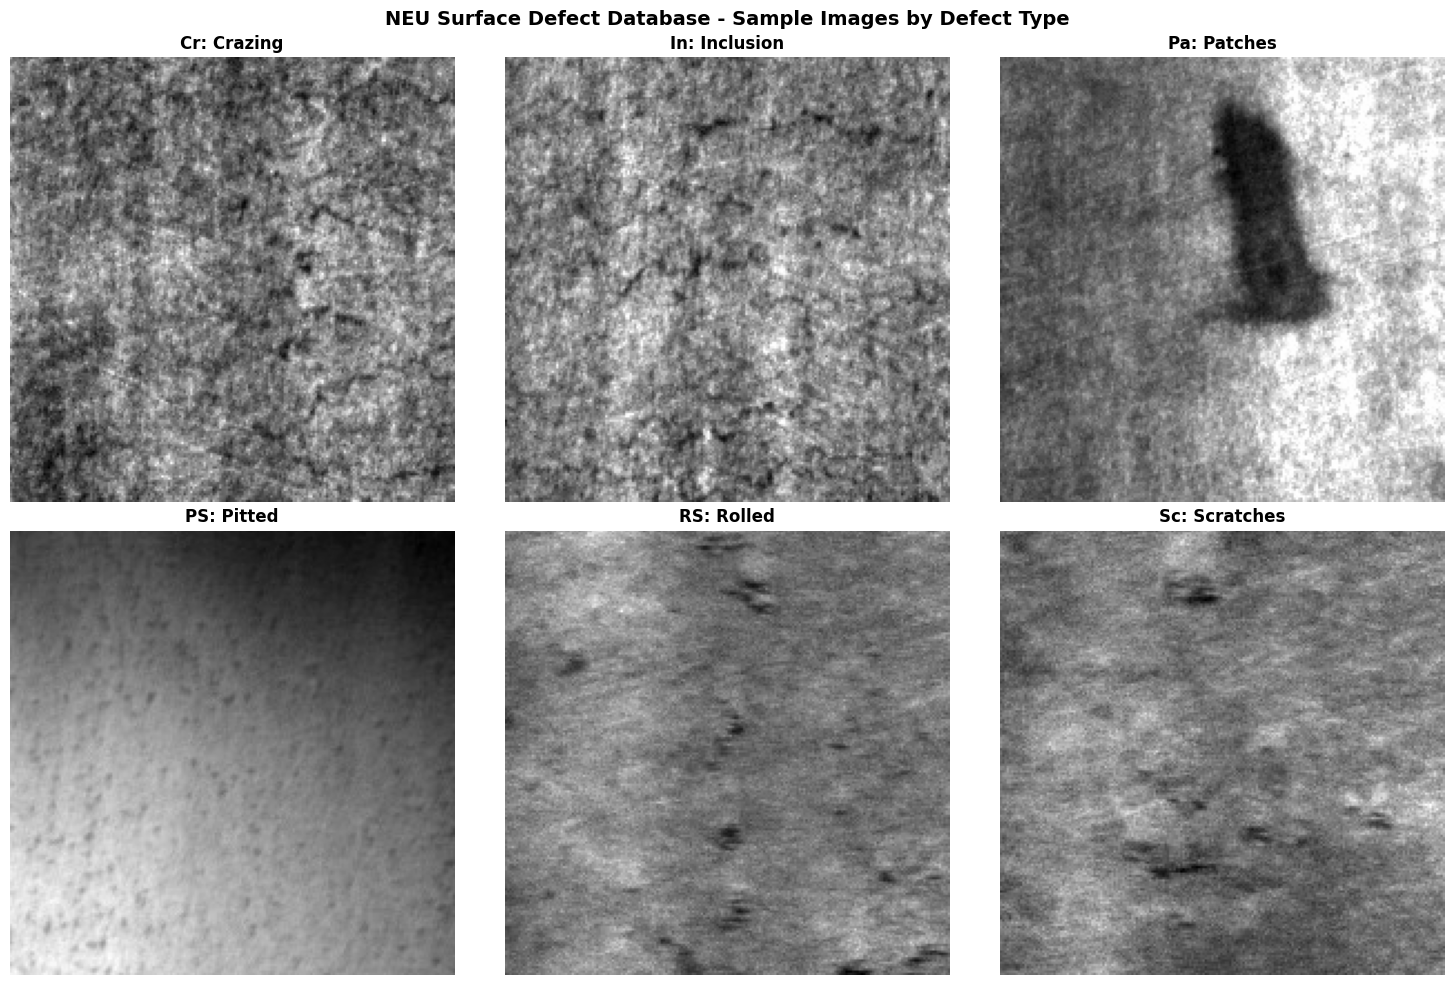


결함 유형 설명:
------------------------------------------------------------
  Cr (Crazing): 표면에 미세한 균열이 거미줄처럼 퍼진 패턴
  In (Inclusion): 제강 과정에서 혼입된 비금속 개재물
  Pa (Patches): 불균일한 산화나 오염으로 인한 얼룩 패턴
  PS (Pitted Surface): 표면에 작은 구멍들이 산재한 피팅 결함
  RS (Rolled-in Scale): 압연 과정에서 스케일이 눌려 들어간 결함
  Sc (Scratches): 기계적 접촉으로 인한 선형 스크래치


In [29]:
# 각 클래스별 샘플 이미지 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (code, name) in enumerate(zip(CLASS_CODES, CLASS_NAMES)):
    # 해당 클래스의 샘플 찾기
    class_indices = np.where(y_train == i)[0]
    sample_idx = class_indices[0]
    
    axes[i].imshow(X_train[sample_idx, :, :, 0], cmap='gray')
    axes[i].set_title(f'{code}: {name}', fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('NEU Surface Defect Database - Sample Images by Defect Type', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n결함 유형 설명:")
print("-" * 60)
defect_descriptions = [
    ("Cr (Crazing)", "표면에 미세한 균열이 거미줄처럼 퍼진 패턴"),
    ("In (Inclusion)", "제강 과정에서 혼입된 비금속 개재물"),
    ("Pa (Patches)", "불균일한 산화나 오염으로 인한 얼룩 패턴"),
    ("PS (Pitted Surface)", "표면에 작은 구멍들이 산재한 피팅 결함"),
    ("RS (Rolled-in Scale)", "압연 과정에서 스케일이 눌려 들어간 결함"),
    ("Sc (Scratches)", "기계적 접촉으로 인한 선형 스크래치")
]
for defect, desc in defect_descriptions:
    print(f"  {defect}: {desc}")

## 3.4 CNN 모델 구성

### 모델 아키텍처 설계

In [14]:
def create_steel_defect_cnn(input_shape=(200, 200, 1), num_classes=6):
    """
    철강 표면 결함 분류를 위한 CNN 모델 생성
    
    구조:
    - 3개의 합성곱 블록 (Conv2D -> BatchNorm -> MaxPooling)
    - 완전연결층 (Flatten -> Dense -> Dropout -> Dense)
    
    Parameters:
        input_shape: 입력 이미지 형태 (H, W, C)
        num_classes: 출력 클래스 수
    
    Returns:
        model: 컴파일된 Keras 모델
    """
    model = Sequential([
        # 첫 번째 합성곱 블록
        # 입력: 200x200x1 -> 출력: 99x99x32
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape,
               padding='valid', name='conv1'),
        BatchNormalization(name='bn1'),
        MaxPooling2D((2, 2), name='pool1'),
        
        # 두 번째 합성곱 블록
        # 입력: 99x99x32 -> 출력: 48x48x64
        Conv2D(64, (3, 3), activation='relu', padding='valid', name='conv2'),
        BatchNormalization(name='bn2'),
        MaxPooling2D((2, 2), name='pool2'),
        
        # 세 번째 합성곱 블록
        # 입력: 48x48x64 -> 출력: 23x23x128
        Conv2D(128, (3, 3), activation='relu', padding='valid', name='conv3'),
        BatchNormalization(name='bn3'),
        MaxPooling2D((2, 2), name='pool3'),
        
        # 분류기 (Classifier)
        Flatten(name='flatten'),
        Dense(256, activation='relu', name='dense1'),
        Dropout(0.5, name='dropout'),
        Dense(num_classes, activation='softmax', name='output')  # 다중 클래스 분류
    ])
    
    return model

# 모델 생성
model = create_steel_defect_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1), 
                                 num_classes=NUM_CLASSES)

# 모델 구조 출력
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                       │ (None, 198, 198, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn1 (BatchNormalization)             │ (None, 198, 198, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 99, 99, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 97, 97, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn2 (BatchNormalization)             │ (None, 97, 97, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 48, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3 (Conv2D)                       │ (None, 46, 46, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn3 (BatchNormalization)             │ (None, 46, 46, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool3 (MaxPooling2D)                 │ (None, 23, 23, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 67712)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense1 (Dense)                       │ (None, 256)                 │      17,334,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,429,638 (66.49 MB)

 Trainable params: 17,429,190 (66.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
# 파라미터 수 상세 계산
print("\n파라미터 수 상세 계산:")
print("=" * 60)

param_details = [
    ("Conv1 (32 filters, 3x3)", "(3*3*1 + 1) * 32", (3*3*1 + 1) * 32),
    ("BatchNorm1", "32 * 4", 32 * 4),
    ("Conv2 (64 filters, 3x3)", "(3*3*32 + 1) * 64", (3*3*32 + 1) * 64),
    ("BatchNorm2", "64 * 4", 64 * 4),
    ("Conv3 (128 filters, 3x3)", "(3*3*64 + 1) * 128", (3*3*64 + 1) * 128),
    ("BatchNorm3", "128 * 4", 128 * 4),
    ("Dense1 (256 neurons)", "(23*23*128 + 1) * 256", (23*23*128 + 1) * 256),
    ("Output (6 classes)", "(256 + 1) * 6", (256 + 1) * 6),
]

total = 0
for name, formula, params in param_details:
    print(f"  {name}:")
    print(f"    Formula: {formula}")
    print(f"    Params: {params:,}")
    total += params

print("-" * 60)
print(f"  Calculated Total: {total:,}")


파라미터 수 상세 계산:
  Conv1 (32 filters, 3x3):
    Formula: (3*3*1 + 1) * 32
    Params: 320
  BatchNorm1:
    Formula: 32 * 4
    Params: 128
  Conv2 (64 filters, 3x3):
    Formula: (3*3*32 + 1) * 64
    Params: 18,496
  BatchNorm2:
    Formula: 64 * 4
    Params: 256
  Conv3 (128 filters, 3x3):
    Formula: (3*3*64 + 1) * 128
    Params: 73,856
  BatchNorm3:
    Formula: 128 * 4
    Params: 512
  Dense1 (256 neurons):
    Formula: (23*23*128 + 1) * 256
    Params: 17,334,528
  Output (6 classes):
    Formula: (256 + 1) * 6
    Params: 1,542
------------------------------------------------------------
  Calculated Total: 17,429,638


## 3.5 모델 컴파일 및 학습

In [16]:
# 모델 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # 정수 레이블 사용
    metrics=['accuracy']
)

print("모델 컴파일 설정:")
print("=" * 50)
print("  Optimizer: Adam (적응형 학습률)")
print("  Loss: sparse_categorical_crossentropy (다중 클래스 분류)")
print("  Metrics: accuracy")

# 콜백 설정
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

print("\nEarly Stopping 설정:")
print("  - Monitor: val_loss")
print("  - Patience: 10 epochs")
print("  - Restore best weights: True")

모델 컴파일 설정:
  Optimizer: Adam (적응형 학습률)
  Loss: sparse_categorical_crossentropy (다중 클래스 분류)
  Metrics: accuracy

Early Stopping 설정:
  - Monitor: val_loss
  - Patience: 10 epochs
  - Restore best weights: True


In [17]:
# 모델 학습
print("\n모델 학습 시작...")
print("=" * 50)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print("\n학습 완료!")
print(f"  실제 학습 Epochs: {len(history.history['loss'])}")
print(f"  최종 학습 정확도: {history.history['accuracy'][-1]:.4f}")
print(f"  최종 검증 정확도: {history.history['val_accuracy'][-1]:.4f}")


모델 학습 시작...
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 693ms/step - accuracy: 0.6250 - loss: 20.1594 - val_accuracy: 0.2500 - val_loss: 34.8375
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 706ms/step - accuracy: 0.6637 - loss: 9.3185 - val_accuracy: 0.2500 - val_loss: 140.5026
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 696ms/step - accuracy: 0.7158 - loss: 4.5101 - val_accuracy: 0.2500 - val_loss: 275.5086
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 676ms/step - accuracy: 0.7083 - loss: 3.2611 - val_accuracy: 0.2500 - val_loss: 413.6635
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 667ms/step - accuracy: 0.7217 - loss: 1.3527 - val_accuracy: 0.2500 - val_loss: 513.4974
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 663ms/step - accuracy: 0.7292 - loss: 1.4989 - val_accuracy: 0.2500 - val_loss: 611.0370
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 667ms/step - accuracy: 0.7143 - loss: 1.0018 - val_accuracy: 0.2500 - val_loss: 691.6567
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 657ms/step - accuracy: 0.727

## 3.6 학습 과정 시각화

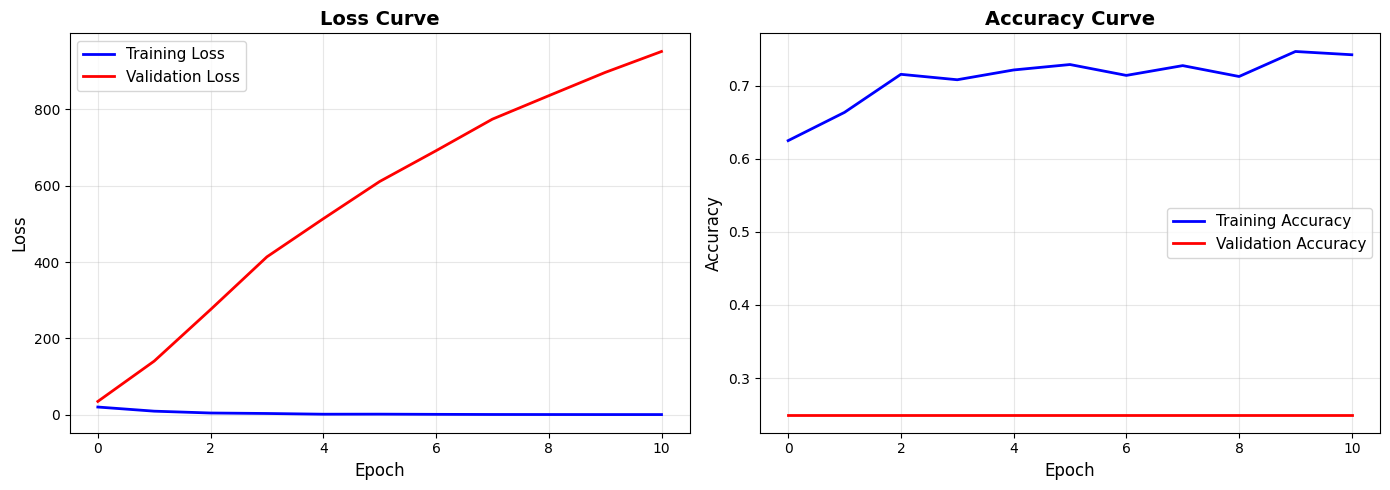


학습 곡선 해석 가이드:
--------------------------------------------------
  - Train/Val 수렴: 정상적인 학습
  - Train 감소, Val 증가: 과적합 (Overfitting)
  - Train/Val 모두 높은 손실: 과소적합 (Underfitting)
  - Val 불안정: 학습률 조정 필요


In [18]:
# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 손실 곡선
ax = axes[0]
ax.plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
ax.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
ax.set_title('Loss Curve', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# 정확도 곡선
ax = axes[1]
ax.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
ax.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
ax.set_title('Accuracy Curve', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n학습 곡선 해석 가이드:")
print("-" * 50)
print("  - Train/Val 수렴: 정상적인 학습")
print("  - Train 감소, Val 증가: 과적합 (Overfitting)")
print("  - Train/Val 모두 높은 손실: 과소적합 (Underfitting)")
print("  - Val 불안정: 학습률 조정 필요")

# 4: 평가 및 해석

## 4.1 테스트 데이터 평가

In [19]:
# 테스트 데이터 평가
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("테스트 데이터 평가 결과:")
print("=" * 50)
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_accuracy:.2%}")

# 예측 수행
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print(f"\n예측 결과:")
print(f"  총 테스트 샘플: {len(y_test):,}장")
print(f"  정확한 예측: {np.sum(y_pred == y_test):,}장")
print(f"  오분류: {np.sum(y_pred != y_test):,}장")

테스트 데이터 평가 결과:
  Test Loss: 32.5941
  Test Accuracy: 25.00%

예측 결과:
  총 테스트 샘플: 144장
  정확한 예측: 36장
  오분류: 108장


## 4.2 혼동 행렬 분석

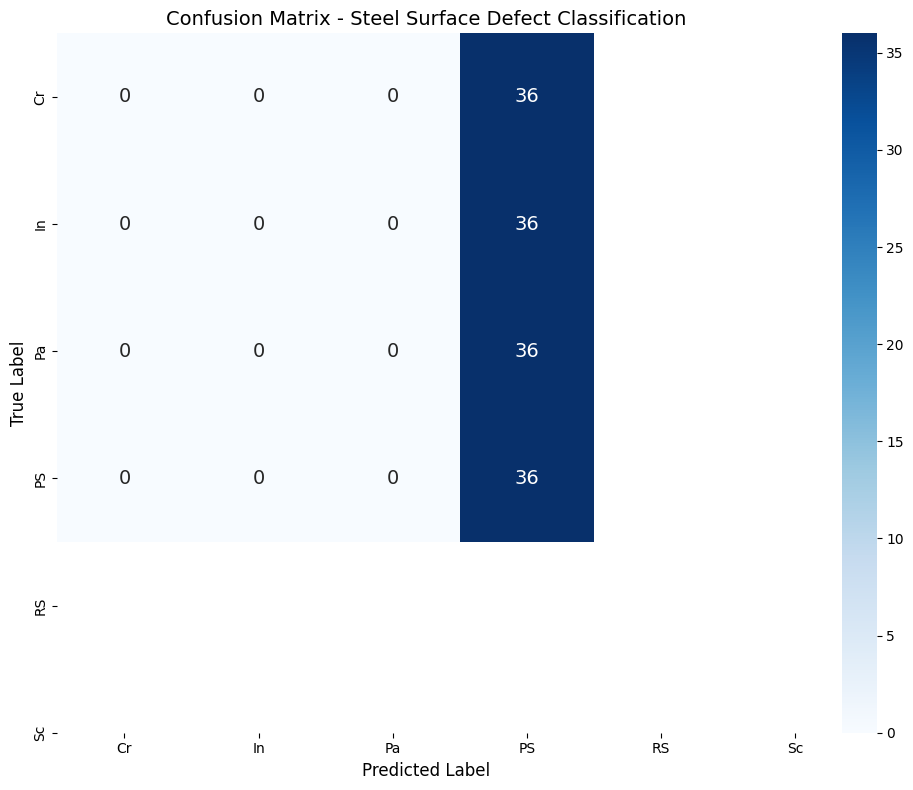


클래스별 성능 분석:
  Cr (Crazing):
    Precision: 0.00%, Recall: 0.00%
  In (Inclusion):
    Precision: 0.00%, Recall: 0.00%
  Pa (Patches):
    Precision: 0.00%, Recall: 0.00%
  PS (Pitted Surface):
    Precision: 25.00%, Recall: 100.00%


IndexError: index 4 is out of bounds for axis 0 with size 4

In [20]:
# 혼동 행렬 계산 및 시각화
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

# 히트맵
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_CODES, yticklabels=CLASS_CODES,
            ax=ax, annot_kws={'size': 14})

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Steel Surface Defect Classification', fontsize=14)

plt.tight_layout()
plt.show()

# 클래스별 성능 분석
print("\n클래스별 성능 분석:")
print("=" * 60)
for i, (code, name) in enumerate(zip(CLASS_CODES, CLASS_NAMES)):
    true_positives = cm[i, i]
    total_actual = np.sum(cm[i, :])
    total_predicted = np.sum(cm[:, i])
    
    recall = true_positives / total_actual if total_actual > 0 else 0
    precision = true_positives / total_predicted if total_predicted > 0 else 0
    
    print(f"  {code} ({name}):")
    print(f"    Precision: {precision:.2%}, Recall: {recall:.2%}")

In [21]:
# 분류 보고서
print("\n분류 보고서 (Classification Report):")
print("=" * 70)
print(classification_report(y_test, y_pred, target_names=CLASS_CODES))


분류 보고서 (Classification Report):


ValueError: Number of classes, 4, does not match size of target_names, 6. Try specifying the labels parameter

## 4.3 오분류 샘플 분석

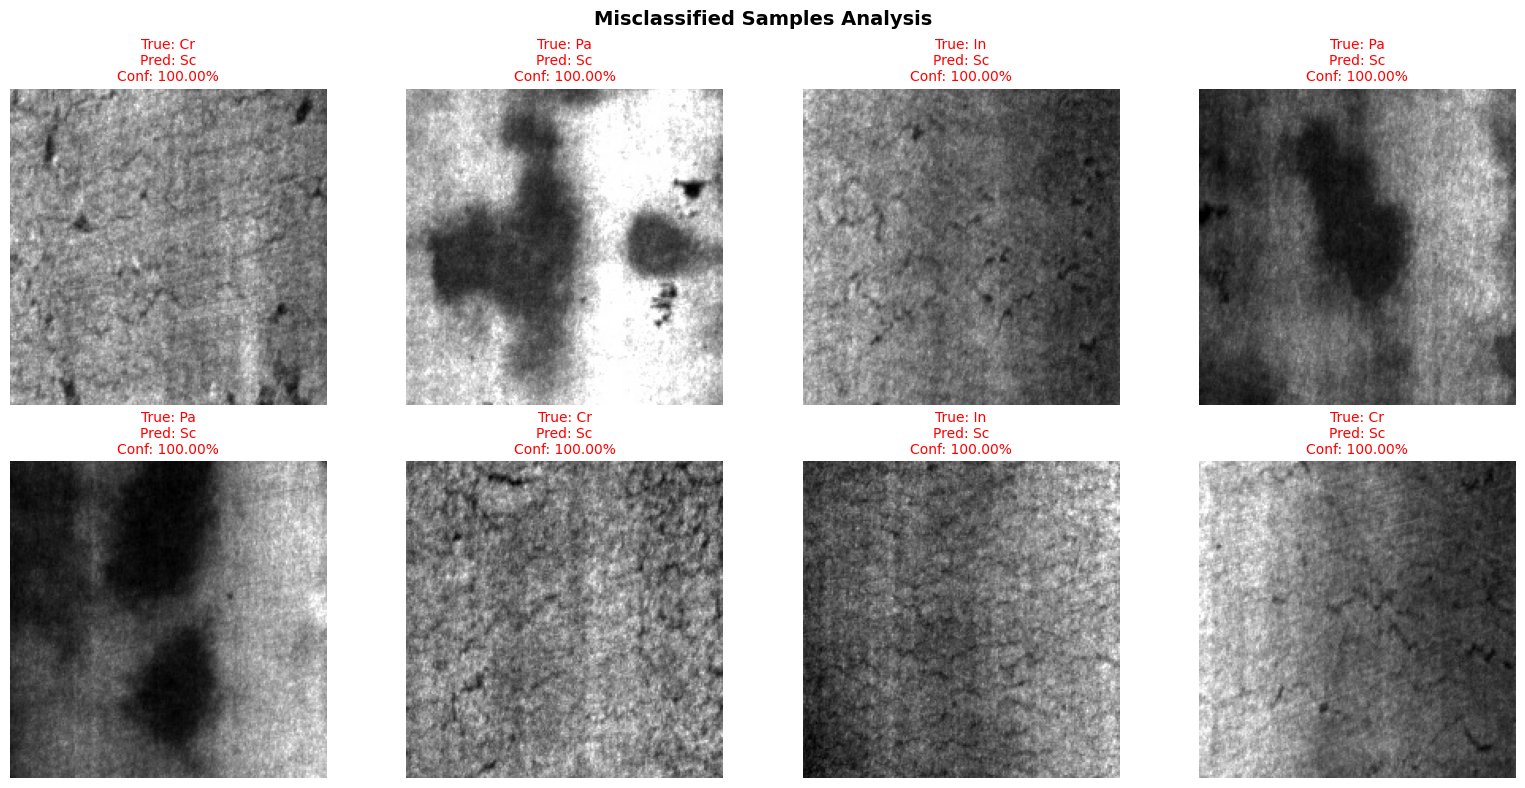


오분류 분석:
  총 오분류 샘플: 108개
  오분류율: 75.00%


In [22]:
# 오분류된 샘플 시각화
wrong_indices = np.where(y_pred != y_test)[0]

if len(wrong_indices) > 0:
    n_samples = min(8, len(wrong_indices))
    sample_indices = np.random.choice(wrong_indices, n_samples, replace=False)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for i, idx in enumerate(sample_indices):
        axes[i].imshow(X_test[idx, :, :, 0], cmap='gray')
        true_label = CLASS_CODES[y_test[idx]]
        pred_label = CLASS_CODES[y_pred[idx]]
        confidence = y_pred_prob[idx, y_pred[idx]]
        
        color = 'red'
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2%}',
                          fontsize=10, color=color)
        axes[i].axis('off')
    
    # 빈 subplot 처리
    for i in range(n_samples, 8):
        axes[i].axis('off')
    
    plt.suptitle('Misclassified Samples Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\n오분류 분석:")
    print(f"  총 오분류 샘플: {len(wrong_indices)}개")
    print(f"  오분류율: {len(wrong_indices)/len(y_test):.2%}")
else:
    print("오분류된 샘플이 없음 (100% 정확도)")

---

# 5. YOLO 소개 및 활용

---

## 5.1 YOLO란?

**YOLO (You Only Look Once)**는 실시간 객체 탐지(Object Detection)를 위한 딥러닝 모델임.

```mermaid
flowchart LR
    subgraph CNN_Classification["CNN 분류"]
        A1["입력 이미지"] --> A2["CNN"] --> A3["클래스 라벨<br/>(전체 이미지)"]
    end
    
    subgraph YOLO_Detection["YOLO 탐지"]
        B1["입력 이미지"] --> B2["YOLO"] --> B3["바운딩 박스 +<br/>클래스 라벨<br/>(다중 객체)"]
    end
```

| 특성 | CNN 분류 | YOLO 탐지 |
|------|----------|----------|
| 출력 | 이미지 전체의 클래스 | 각 객체의 위치 + 클래스 |
| 객체 수 | 1개 (전체 이미지) | 다수 가능 |
| 위치 정보 | 없음 | 바운딩 박스 (x, y, w, h) |
| 적용 예시 | 불량/정상 분류 | 결함 위치 검출 |

## 5.2 YOLO의 핵심 아이디어

YOLO는 이미지를 그리드로 나누어 한 번의 순전파(Forward Pass)로 모든 객체를 탐지함:

```mermaid
flowchart TB
    A["입력 이미지"] --> B["S x S Grid로 분할"]
    B --> C["각 Grid Cell에서<br/>B개의 Bounding Box 예측"]
    C --> D["각 Box에 대해:<br/>- (x, y, w, h): 위치<br/>- confidence: 신뢰도<br/>- class probabilities: 클래스 확률"]
    D --> E["Non-Maximum Suppression<br/>(중복 제거)"]
    E --> F["최종 탐지 결과"]
```

**YOLO의 출력 구조:**

각 그리드 셀은 다음을 예측함:
- $x, y$: 바운딩 박스 중심 좌표 (셀 내 상대 위치)
- $w, h$: 바운딩 박스 너비, 높이 (이미지 대비 비율)
- $\text{confidence}$: $P(\text{Object}) \times \text{IoU}$
- $P(\text{Class}_i | \text{Object})$: 조건부 클래스 확률

## 5.3 YOLO 활용 예시 (Ultralytics YOLOv8)

실제 제조 현장에서 YOLO를 활용하는 방법을 간략히 소개함:

In [24]:
# YOLO를 활용한 결함 탐지 예시 코드
# (실행을 위해서는 ultralytics 패키지 설치 필요)

from ultralytics import YOLO

# 1. 사전 학습된 모델 로드
model = YOLO('yolov8n.pt')  # nano 모델 (가벼움)

# 2. 커스텀 데이터로 학습 (결함 탐지용)
# 데이터셋 구조:
# dataset/
#   train/
#     images/
#     labels/  # YOLO 형식: class x_center y_center width height
#   val/
#     images/
#     labels/

results = model.train(
    data='defect_dataset.yaml',  # 데이터셋 설정 파일
    epochs=100,
    imgsz=640,
    batch=16
)

# 3. 추론 (새 이미지에서 결함 탐지)
results = model.predict(
    source='test_image.jpg',
    conf=0.5,  # 신뢰도 임계값
    save=True  # 결과 저장
)

# 4. 결과 확인
for result in results:
    boxes = result.boxes  # 바운딩 박스
    for box in boxes:
        cls = int(box.cls)  # 클래스
        conf = float(box.conf)  # 신뢰도
        xyxy = box.xyxy  # 좌표 (x1, y1, x2, y2)
        print(f"Class: {cls}, Confidence: {conf:.2f}, Box: {xyxy}")

ModuleNotFoundError: No module named 'ultralytics'

## 5.4 CNN 분류 vs YOLO 탐지 비교

| 측면 | CNN 분류 | YOLO 탐지 |
|------|----------|----------|
| **목적** | 이미지 전체의 클래스 분류 | 객체의 위치와 클래스 동시 탐지 |
| **출력** | 클래스 확률 벡터 | 바운딩 박스 + 클래스 + 신뢰도 |
| **적용 예시** | "이 이미지는 스크래치 결함이다" | "위치 (100, 50)에 스크래치 결함이 있다" |
| **데이터 라벨링** | 이미지 레벨 라벨 | 바운딩 박스 라벨 필요 |
| **계산 복잡도** | 상대적으로 낮음 | 상대적으로 높음 |
| **실시간 처리** | 가능 | 가능 (YOLO의 강점) |

**제조 현장에서의 선택 기준:**
- 결함 **유무만** 판단: CNN 분류
- 결함 **위치까지** 필요: YOLO 탐지
- 다수의 결함을 동시에 탐지: YOLO 탐지

# 핵심 정리

| 주제 | 핵심 내용 |
|------|----------|
| 합성곱 연산 | $(I * K)(i,j) = \sum_m \sum_n I(i+m, j+n) \cdot K(m,n)$ |
| 다채널 합성곱 | $O_c(i,j) = b_c + \sum_{c_{in}} \sum_m \sum_n I_{c_{in}}(i+m,j+n) \cdot K_{c,c_{in}}(m,n)$ |
| 특성 맵 크기 | $O = \lfloor \frac{W - K + 2P}{S} \rfloor + 1$ |
| Max Pooling | $y_{ij} = \max_{(m,n) \in R_{ij}} x_{mn}$ |
| CNN 구조 | Conv2D -> MaxPooling -> Flatten -> Dense |
| 다중 분류 | 출력: softmax, 손실: categorical_crossentropy |
| YOLO | 실시간 객체 탐지 (위치 + 클래스) |

## 학습 체크리스트

| 항목 | 확인 |
|------|------|
| 합성곱 연산의 수학적 정의와 계산 과정 이해 | [ ] |
| 다채널 합성곱에서 필터와 채널의 관계 이해 | [ ] |
| 특성 맵 크기 계산 공식 적용 | [ ] |
| Max Pooling의 역할과 동작 원리 이해 | [ ] |
| Conv2D, MaxPooling2D 층 구성 | [ ] |
| BatchNormalization의 효과 이해 | [ ] |
| 다중 클래스 분류 설정 (softmax, categorical_crossentropy) | [ ] |
| 혼동 행렬로 클래스별 성능 분석 | [ ] |
| YOLO의 기본 개념과 CNN 분류와의 차이 이해 | [ ] |

---

# [참고자료] 심화 학습

> 아래 내용은 심화에 관심 있는 학생 위주로 한번 확인해볼 것

## A. 데이터 증강 (Data Augmentation)

데이터 증강은 원본 이미지를 변환하여 학습 데이터를 늘리는 기법으로, 과적합을 방지하고 모델의 일반화 성능을 향상시킴:

In [ ]:
# 데이터 증강 설정 예시
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 학습용 데이터 증강
train_datagen = ImageDataGenerator(
    rescale=1./255,           # 정규화
    rotation_range=15,        # 무작위 회전 (도)
    width_shift_range=0.1,    # 수평 이동
    height_shift_range=0.1,   # 수직 이동
    zoom_range=0.1,           # 확대/축소
    horizontal_flip=True,     # 수평 반전
    fill_mode='nearest'       # 빈 공간 채우기
)

# 검증/테스트용 (증강 없음, 정규화만)
val_datagen = ImageDataGenerator(rescale=1./255)

print("데이터 증강 설정:")
print("-" * 40)
print("  - rotation_range: 15도 (무작위 회전)")
print("  - width/height_shift_range: 10% (이동)")
print("  - zoom_range: 10% (확대/축소)")
print("  - horizontal_flip: True (수평 반전)")
print("\n제조업에서 데이터 증강의 효과:")
print("  - 결함의 다양한 위치/방향에 대한 강건성 확보")
print("  - 제한된 불량 샘플을 효과적으로 활용")

## B. 특성 맵 시각화

CNN이 실제로 어떤 특징을 학습하는지 시각화를 통해 확인할 수 있음:

In [ ]:
# 특성 맵 시각화 함수
def visualize_feature_maps(model, image, layer_names=None):
    """
    CNN의 중간 층 출력(특성 맵)을 시각화
    
    Parameters:
        model: 학습된 CNN 모델
        image: 입력 이미지 (H, W, C)
        layer_names: 시각화할 층 이름 리스트
    """
    if layer_names is None:
        layer_names = [layer.name for layer in model.layers if 'conv' in layer.name]
    
    # 중간 층 출력을 가져오는 모델 생성
    outputs = [model.get_layer(name).output for name in layer_names]
    feature_model = keras.Model(inputs=model.input, outputs=outputs)
    
    # 배치 차원 추가
    if len(image.shape) == 3:
        image = np.expand_dims(image, axis=0)
    
    # 특성 맵 추출
    feature_maps = feature_model.predict(image, verbose=0)
    
    # 시각화
    for layer_name, fmap in zip(layer_names, feature_maps):
        n_features = min(fmap.shape[-1], 8)  # 최대 8개 필터만 표시
        
        fig, axes = plt.subplots(1, n_features, figsize=(16, 2))
        fig.suptitle(f'Feature Maps: {layer_name}', fontsize=12)
        
        for i in range(n_features):
            axes[i].imshow(fmap[0, :, :, i], cmap='viridis')
            axes[i].set_title(f'Filter {i}')
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()

# 샘플 이미지로 특성 맵 시각화
print("특성 맵 시각화:")
print("=" * 50)
sample_image = X_test[0]
visualize_feature_maps(model, sample_image)